# Generalized Onset Table — Exploratory Analysis

Covers all 8 task types: parity, exactK, rowK, rowVarK, globalK, rowOnly, latinSq, sudoku.

Key onset columns:
- `rule_onset_acc90` — first sustained step where rule accuracy ≥ 90%
- `mem_onset_mem10` / `mem_onset_stat` — memorization onset
- `novel_onset_05` — novel_valid = rule_acc − mem_ratio ≥ 0.5
- `stat_mem_frac` = N / support_size (data-to-support ratio)

All metrics renormalized to fraction of all generated samples.

In [57]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from circuit_toolkit.plot_utils import saveallforms
import matplotlib
sys.path.insert(0, os.path.dirname(os.getcwd()))

matplotlib.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 11,
})
ONSET_CSV = '../outputs/generalized_onset_table.csv'

df = pd.read_csv(ONSET_CSV)
print(f'{len(df)} experiments  |  {df.task_type.nunique()} task types')
df.groupby('task_type').size()

128 experiments  |  8 task types


task_type
exactK      7
globalK     2
latinSq    10
parity     98
rowK        2
rowOnly     3
rowVarK     4
sudoku      2
dtype: int64

In [110]:
FIGDIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/beyond_parity_figures"

In [58]:
# ── colour palette per task type ─────────────────────────────────────────────
TASK_COLORS = {
    'parity':   '#1f77b4',
    'exactK':   '#ff7f0e',
    'rowK':     '#2ca02c',
    'rowVarK':  '#d62728',
    'globalK':  '#9467bd',
    'rowOnly':  '#8c564b',
    'latinSq':  '#e377c2',
    'sudoku':   '#17becf',
}
TASK_ORDER = list(TASK_COLORS.keys())

df['task_type'] = pd.Categorical(df['task_type'], categories=TASK_ORDER, ordered=True)
df

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
0,DiT_B_latinSq_n5_N4096_onehot,latinSq,DiT,B,1,4096,5.0,NaN,NaN,NaN,...,40208.0,NaN,59216.0,444064.0,NaN,NaN,140960.0,1412.0,6280.0,NaN
1,DiT_B_latinSq_n5_N4096_scalar,latinSq,DiT,B,1,4096,5.0,NaN,NaN,NaN,...,9224.0,NaN,28688.0,50512.0,458400.0,516768.0,31504.0,268.0,340.0,14352.0
2,DiT_B_latinSq_n6_N4096_onehot,latinSq,DiT,B,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2724.0,19984.0,NaN
3,DiT_B_latinSq_n6_N4096_scalar,latinSq,DiT,B,1,4096,6.0,NaN,NaN,NaN,...,24848.0,NaN,174752.0,212640.0,271008.0,356000.0,174752.0,548.0,7560.0,85840.0
4,DiT_mini_exactK_N4096_D36_K12,exactK,DiT,mini,1,4096,NaN,36.0,12.0,NaN,...,NaN,NaN,657056.0,803488.0,NaN,NaN,657056.0,324.0,996.0,3172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,GPT_nano_parity_N4096_D36_G36_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,7304.0,8328.0,9096.0,9608.0,7304.0,1.0,1556.0,NaN
124,GPT_nano_parity_N4096_D36_G3_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,5768.0,6152.0,6792.0,7304.0,5768.0,188.0,196.0,220.0
125,GPT_nano_parity_N4096_D36_G4_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,6792.0,7304.0,7688.0,8328.0,6792.0,900.0,2180.0,2308.0
126,GPT_nano_parity_N4096_D36_G6_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,6920.0,7304.0,7816.0,8456.0,6920.0,3812.0,NaN,NaN


## 1. Rule-onset reach rate by task type

What fraction of runs reached 90% rule accuracy within the training budget?

/tmp/ipykernel_1827802/425046306.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reach = df.groupby('task_type').apply(
/tmp/ipykernel_1827802/425046306.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reach = df.groupby('task_type').apply(


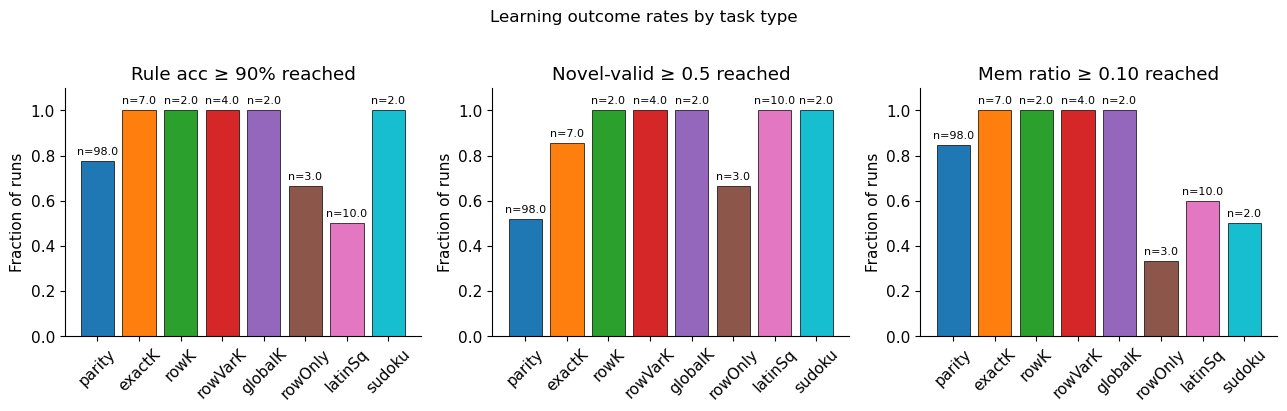

In [59]:
reach = df.groupby('task_type').apply(
    lambda g: pd.Series({
        'n_runs':          len(g),
        'rule90_rate':     g['rule_onset_acc90'].notna().mean(),
        'novel05_rate':    g['novel_onset_05'].notna().mean(),
        'mem10_rate':      g['mem_onset_mem10'].notna().mean(),
    })
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
metrics = [
    ('rule90_rate',  'Rule acc ≥ 90% reached'),
    ('novel05_rate', 'Novel-valid ≥ 0.5 reached'),
    ('mem10_rate',   'Mem ratio ≥ 0.10 reached'),
]
for ax, (col, title) in zip(axes, metrics):
    colors = [TASK_COLORS.get(t, 'gray') for t in reach['task_type']]
    bars = ax.bar(reach['task_type'], reach[col], color=colors, edgecolor='k', linewidth=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Fraction of runs')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    # annotate n_runs
    for bar, n in zip(bars, reach['n_runs']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={n}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Learning outcome rates by task type', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 2. Rule onset step distribution by task type

In [60]:
df.query("task_type=='parity'")

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
19,DiT_mini_parity_N32768_D36_G4_even_rep2,parity,DiT,mini,2,32768,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,DiT_mini_parity_N32768_D36_G4_even_rep3,parity,DiT,mini,3,32768,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,DiT_mini_parity_N32768_D36_G6_even_rep2,parity,DiT,mini,2,32768,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,DiT_mini_parity_N32768_D36_G6_even_rep3,parity,DiT,mini,3,32768,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,DiT_mini_parity_N4096_D36_G12_even_rep2,parity,DiT,mini,2,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,541344.0,698016.0,989856.0,NaN,541344.0,484.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,GPT_nano_parity_N4096_D36_G36_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,7304.0,8328.0,9096.0,9608.0,7304.0,1.0,1556.0,NaN
124,GPT_nano_parity_N4096_D36_G3_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,5768.0,6152.0,6792.0,7304.0,5768.0,188.0,196.0,220.0
125,GPT_nano_parity_N4096_D36_G4_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,6792.0,7304.0,7688.0,8328.0,6792.0,900.0,2180.0,2308.0
126,GPT_nano_parity_N4096_D36_G6_even,parity,GPT,nano,1,4096,NaN,36.0,NaN,NaN,...,NaN,NaN,6920.0,7304.0,7816.0,8456.0,6920.0,3812.0,NaN,NaN


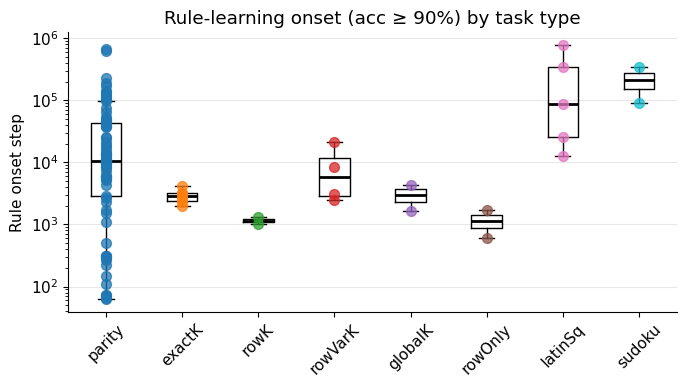

In [61]:
fig, ax = plt.subplots(figsize=(7, 4))

df_has_rule = df[df['rule_onset_acc90'].notna()].copy()

for tt in TASK_ORDER:
    sub = df_has_rule[df_has_rule['task_type'] == tt]
    if len(sub) == 0:
        continue
    vals = sub['rule_onset_acc90'].values   # convert to k-steps
    ax.scatter([tt] * len(vals), vals,
               color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3,
               label=tt)
    ax.boxplot(vals, positions=[TASK_ORDER.index(tt)],
               widths=0.4, patch_artist=False,
               medianprops=dict(color='k', linewidth=2),
               flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER)))
ax.set_xticklabels(TASK_ORDER, rotation=45)
ax.set_ylabel('Rule onset step')
ax.set_title('Rule-learning onset (acc ≥ 90%) by task type')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
df.query("model_arch=='DiT' and model_size=='mini' and rule_onset_acc90.notna()")

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
4,DiT_mini_exactK_N4096_D36_K12,exactK,DiT,mini,1,4096,NaN,36.0,12.0,NaN,...,NaN,NaN,657056.0,803488.0,NaN,NaN,657056.0,324.0,996.0,3172.0
5,DiT_mini_exactK_N4096_D36_K18,exactK,DiT,mini,1,4096,NaN,36.0,18.0,NaN,...,NaN,NaN,580256.0,726688.0,970400.0,NaN,580256.0,412.0,1988.0,4132.0
6,DiT_mini_exactK_N4096_D36_K3,exactK,DiT,mini,1,4096,NaN,36.0,3.0,NaN,...,NaN,NaN,404.0,612.0,804.0,2148.0,511648.0,460.0,NaN,NaN
7,DiT_mini_exactK_N4096_D36_K4,exactK,DiT,mini,1,4096,NaN,36.0,4.0,NaN,...,NaN,NaN,241312.0,290464.0,333472.0,392864.0,281248.0,404.0,820.0,5000.0
8,DiT_mini_exactK_N4096_D36_K6,exactK,DiT,mini,1,4096,NaN,36.0,6.0,NaN,...,NaN,NaN,341664.0,416416.0,535200.0,758432.0,341664.0,396.0,1044.0,2852.0
9,DiT_mini_exactK_N4096_D36_K8,exactK,DiT,mini,1,4096,NaN,36.0,8.0,NaN,...,NaN,NaN,418464.0,538272.0,717472.0,968352.0,418464.0,364.0,916.0,3268.0
10,DiT_mini_exactK_N4096_D36_K9,exactK,DiT,mini,1,4096,NaN,36.0,9.0,NaN,...,NaN,NaN,518816.0,657056.0,898720.0,NaN,518816.0,332.0,1028.0,2532.0
11,DiT_mini_globalK15_n6_N4096,globalK,DiT,mini,1,4096,6.0,NaN,NaN,"[1, 5]",...,NaN,NaN,649888.0,747168.0,828064.0,917152.0,703136.0,532.0,676.0,2116.0
12,DiT_mini_globalK24_n6_N4096,globalK,DiT,mini,1,4096,6.0,NaN,NaN,"[2, 4]",...,NaN,NaN,565920.0,753312.0,NaN,NaN,570016.0,1764.0,2532.0,4356.0
13,DiT_mini_latinSq_n5_N4096_onehot,latinSq,DiT,mini,1,4096,5.0,NaN,NaN,NaN,...,63312.0,NaN,112288.0,NaN,NaN,NaN,194208.0,3460.0,10768.0,NaN


In [65]:
df_has_rule.columns


Index(['exp_name', 'task_type', 'model_arch', 'model_size', 'rep', 'N',
       'n_size', 'D', 'K', 'K_list', 'G', 'encoding', 'n_layer', 'n_embd',
       'n_head', 'lr', 'wd', 'nsteps', 'support_size', 'stat_mem_frac',
       'stat_mem_thresh', 'rule_onset_acc85', 'rule_onset_acc90',
       'rule_onset_acc95', 'row_onset_90', 'col_onset_90', 'block_onset_90',
       'mem_onset_mem10', 'mem_onset_mem20', 'mem_onset_mem35',
       'mem_onset_mem50', 'mem_onset_stat', 'novel_onset_01', 'novel_onset_05',
       'novel_onset_09'],
      dtype='object')

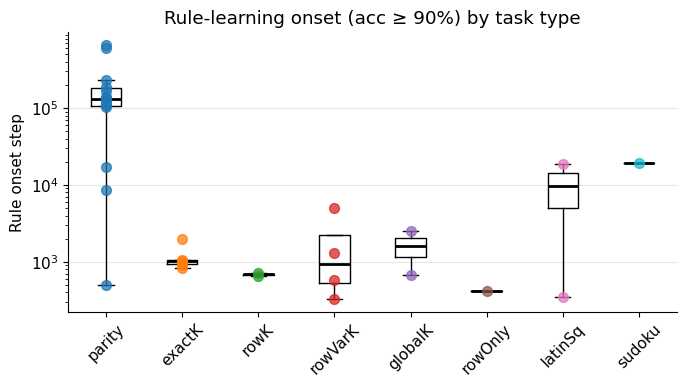

In [71]:
fig, ax = plt.subplots(figsize=(7, 4))

df_has_rule = df.query("model_arch=='DiT' and model_size=='mini' and novel_onset_05.notna() and encoding!='onehot'")

for tt in TASK_ORDER:
    sub = df_has_rule[df_has_rule['task_type'] == tt]
    if len(sub) == 0:
        continue
    vals = sub['novel_onset_05'].values   # convert to k-steps
    ax.scatter([tt] * len(vals), vals,
               color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3,
               label=tt)
    ax.boxplot(vals, positions=[TASK_ORDER.index(tt)],
               widths=0.4, patch_artist=False,
               medianprops=dict(color='k', linewidth=2),
               flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER)))
ax.set_xticklabels(TASK_ORDER, rotation=45)
ax.set_ylabel('Rule onset step')
ax.set_title('Rule-learning onset (acc ≥ 90%) by task type')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

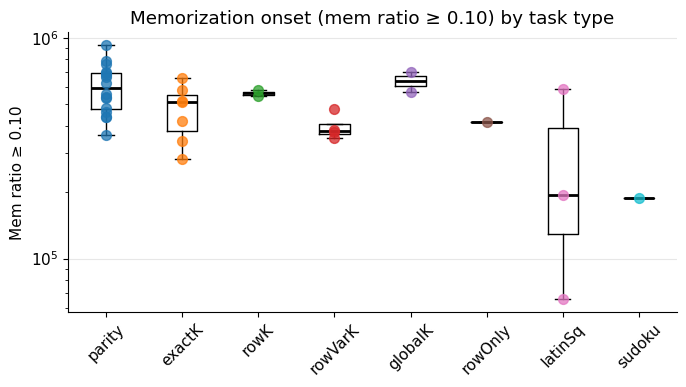

In [55]:
fig, ax = plt.subplots(figsize=(7, 4))

df_has_rule = df.query("model_arch=='DiT' and model_size=='mini' and mem_onset_stat.notna()")

for tt in TASK_ORDER:
    sub = df_has_rule[df_has_rule['task_type'] == tt]
    if len(sub) == 0:
        continue
    vals = sub['mem_onset_stat'].values   # convert to k-steps
    ax.scatter([tt] * len(vals), vals,
               color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3,
               label=tt)
    ax.boxplot(vals, positions=[TASK_ORDER.index(tt)],
               widths=0.4, patch_artist=False,
               medianprops=dict(color='k', linewidth=2),
               flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER)))
ax.set_xticklabels(TASK_ORDER, rotation=45)
ax.set_ylabel('Mem ratio ≥ 0.10')
ax.set_title('Memorization onset (mem ratio ≥ 0.10) by task type')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Binary samples

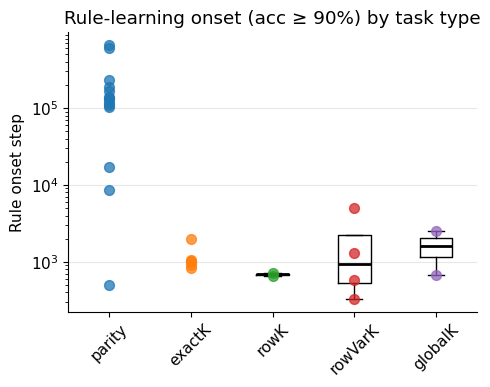

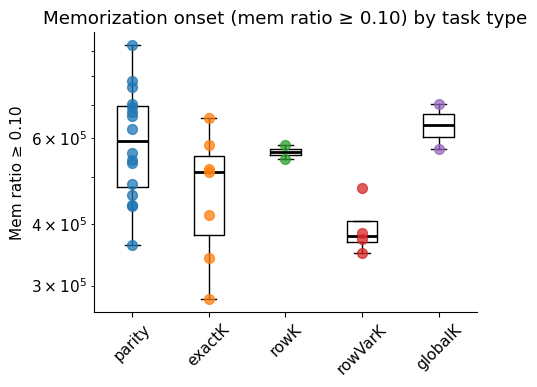

In [75]:
fig, ax = plt.subplots(figsize=(5, 4))

df_has_rule = df.query("model_arch=='DiT' and model_size=='mini' and encoding!='onehot'")

for tt in TASK_ORDER[:-3]:
    sub = df_has_rule[df_has_rule['task_type'] == tt]
    if len(sub) == 0:
        continue
    vals = sub['novel_onset_05'].values   # convert to k-steps
    ax.scatter([tt] * len(vals), vals,
               color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3,
               label=tt)
    ax.boxplot(vals, positions=[TASK_ORDER.index(tt)],
               widths=0.4, patch_artist=False,
               medianprops=dict(color='k', linewidth=2),
               flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER))[:-3])
ax.set_xticklabels(TASK_ORDER[:-3], rotation=45)
ax.set_ylabel('Rule onset step')
ax.set_title('Rule-learning onset (acc ≥ 90%) by task type')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(5, 4))

df_has_rule = df.query("model_arch=='DiT' and model_size=='mini' and mem_onset_stat.notna()")

for tt in TASK_ORDER[:-3]:
    sub = df_has_rule[df_has_rule['task_type'] == tt]
    if len(sub) == 0:
        continue
    vals = sub['mem_onset_stat'].values   # convert to k-steps
    ax.scatter([tt] * len(vals), vals,
               color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3,
               label=tt)
    ax.boxplot(vals, positions=[TASK_ORDER.index(tt)],
               widths=0.4, patch_artist=False,
               medianprops=dict(color='k', linewidth=2),
               flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER))[:-3])
ax.set_xticklabels(TASK_ORDER[:-3], rotation=45)
ax.set_ylabel('Mem ratio ≥ 0.10')
ax.set_title('Memorization onset (mem ratio ≥ 0.10) by task type')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

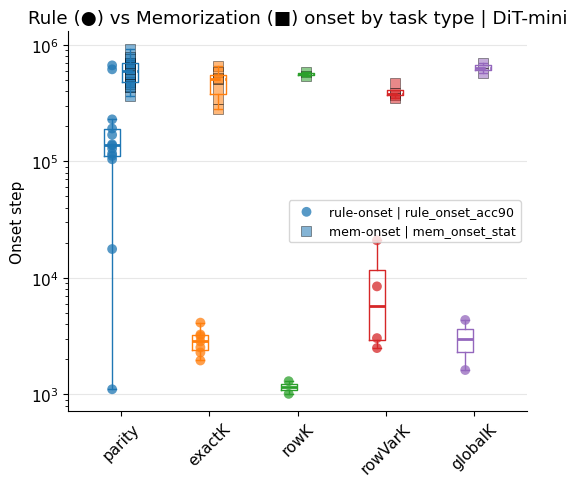

In [109]:
fig, ax = plt.subplots(figsize=(5.5, 5))

rule_col_name = 'rule_onset_acc90'
mem_col_name = 'mem_onset_stat'

# Data: rule onset (novel_onset_05)
df_rule = df.query("model_arch=='DiT' and model_size=='mini' and N==4096")
df_rule = df_rule[df_rule[rule_col_name].notna()]
# Data: mem onset (mem_onset_stat)
df_mem = df.query("model_arch=='DiT' and model_size=='mini' and N==4096")
df_mem = df_mem[df_mem[mem_col_name].notna()]

for i, tt in enumerate(TASK_ORDER[:-3]):
    # Rule onset
    sub_rule = df_rule[df_rule['task_type'] == tt]
    vals_rule = sub_rule[rule_col_name].values
    # Memorization onset
    sub_mem = df_mem[df_mem['task_type'] == tt]
    vals_mem = sub_mem[mem_col_name].values

    if len(vals_rule) > 0:
        ax.scatter([i-0.10]*len(vals_rule), vals_rule,
                   color=TASK_COLORS[tt], s=50, alpha=0.75, zorder=3, label=f"rule-onset | {rule_col_name}" if i==0 else None, marker="o", edgecolor='none')
        ax.boxplot(vals_rule, positions=[i-0.10], widths=0.18, patch_artist=False,
                   medianprops=dict(color=TASK_COLORS[tt], linewidth=2),
                   boxprops=dict(color=TASK_COLORS[tt]), whiskerprops=dict(color=TASK_COLORS[tt]),
                   capprops=dict(color=TASK_COLORS[tt]),
                   flierprops=dict(marker=''))
    if len(vals_mem) > 0:
        ax.scatter([i+0.10]*len(vals_mem), vals_mem,
                   color=TASK_COLORS[tt], s=50, alpha=0.55, zorder=2, label=f"mem-onset | {mem_col_name}" if i==0 else None, marker="s", edgecolor='k', linewidths=0.5)
        ax.boxplot(vals_mem, positions=[i+0.10], widths=0.18, patch_artist=False,
                   medianprops=dict(color=TASK_COLORS[tt], linewidth=2, linestyle='dashed'),
                   boxprops=dict(color=TASK_COLORS[tt]), whiskerprops=dict(color=TASK_COLORS[tt]),
                   capprops=dict(color=TASK_COLORS[tt]),
                   flierprops=dict(marker=''))

ax.set_yscale("log")
ax.set_xticks(range(len(TASK_ORDER))[:-3])
ax.set_xticklabels(TASK_ORDER[:-3], rotation=45)
ax.set_ylabel('Onset step')
ax.set_title('Rule (●) vs Memorization (■) onset by task type | DiT-mini')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.3)
# Only draw legend once for marker distinction
handles, labels = [], []
for h, l in zip(*ax.get_legend_handles_labels()):
    if l not in labels:  # unique labels only
        handles.append(h)
        labels.append(l)
if handles:
    ax.legend(handles, labels, fontsize=9, loc='right')
plt.tight_layout()
saveallforms(FIGDIR, 'DiT-mini_rule_mem_onset_by_task_binary_samples', fig)
plt.show()

## 3. Parity: rule onset vs. group size G, for different N and architectures

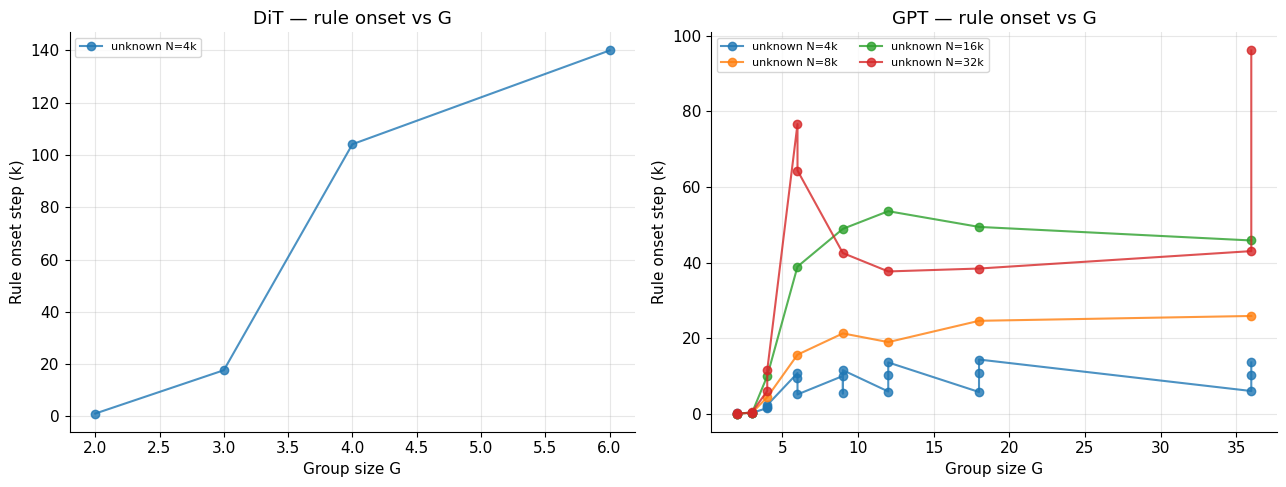

In [6]:
par = df[df['task_type'] == 'parity'].copy()

# focus on standard runs (no lr/wd sweeps, no rep>1 new runs)
par_clean = par[
    ~par['exp_name'].str.contains('lr|wd', case=False) &
    par['rule_onset_acc90'].notna()
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, arch in zip(axes, ['DiT', 'GPT']):
    sub = par_clean[par_clean['model_arch'] == arch]
    for (size, N_val), g in sub.groupby(['model_size', 'N']):
        g_sorted = g.sort_values('G')
        label = f'{size} N={int(N_val)//1000}k'
        ax.plot(g_sorted['G'], g_sorted['rule_onset_acc90'] / 1000,
                marker='o', label=label, alpha=0.8)
    ax.set_xlabel('Group size G')
    ax.set_ylabel('Rule onset step (k)')
    ax.set_title(f'{arch} — rule onset vs G')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Novel-valid onset vs rule onset — do models memorize before generalizing?

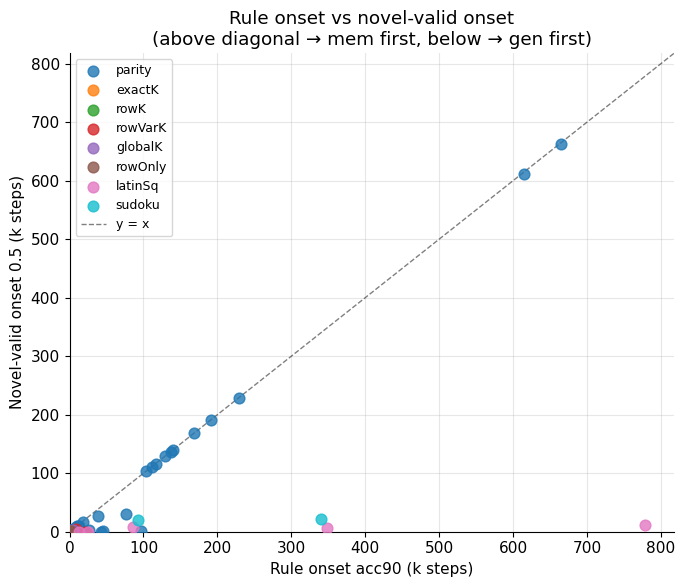

In [7]:
df_both = df[
    df['rule_onset_acc90'].notna() &
    df['novel_onset_05'].notna()
].copy()

fig, ax = plt.subplots(figsize=(7, 6))

for tt in TASK_ORDER:
    sub = df_both[df_both['task_type'] == tt]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['rule_onset_acc90'] / 1000,
        sub['novel_onset_05'] / 1000,
        color=TASK_COLORS[tt], s=60, alpha=0.8, label=tt, zorder=3
    )

lims = [0, df_both[['rule_onset_acc90','novel_onset_05']].max().max() / 1000 * 1.05]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Rule onset acc90 (k steps)')
ax.set_ylabel('Novel-valid onset 0.5 (k steps)')
ax.set_title('Rule onset vs novel-valid onset\n(above diagonal → mem first, below → gen first)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. stat_mem_frac (N / support_size) — data regime across tasks

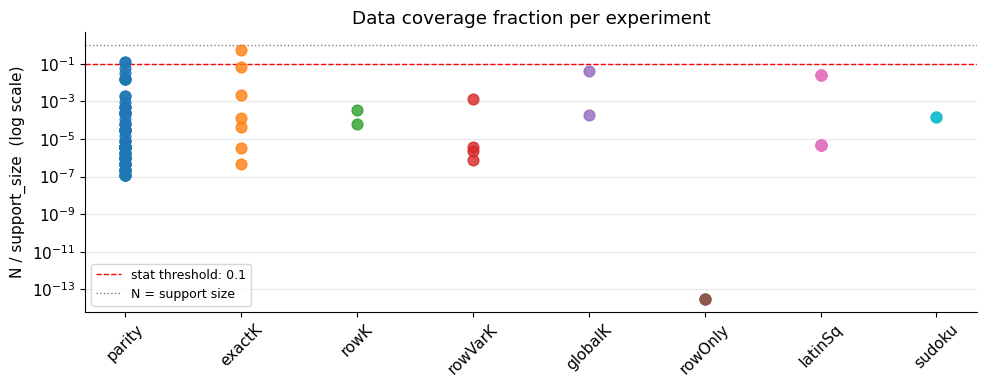

In [8]:
df_frac = df[df['stat_mem_frac'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 4))

for tt in TASK_ORDER:
    sub = df_frac[df_frac['task_type'] == tt]
    if len(sub) == 0:
        continue
    ax.scatter([tt] * len(sub), sub['stat_mem_frac'],
               color=TASK_COLORS[tt], s=60, alpha=0.8, zorder=3)

ax.axhline(0.1, color='red', lw=1, ls='--', label='stat threshold: 0.1')
ax.axhline(1.0, color='gray', lw=1, ls=':', label='N = support size')
ax.set_yscale('log')
ax.set_ylabel('N / support_size  (log scale)')
ax.set_title('Data coverage fraction per experiment')
ax.set_xticks(range(len(TASK_ORDER)))
ax.set_xticklabels(TASK_ORDER, rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Non-binary value samples rules: latinSq vs rowOnly vs sudoku (DiT-mini n=6)

In [114]:
grid_tasks = df[
    df['task_type'].isin(['rowOnly', 'latinSq', 'sudoku'])
    # (df['n_size'] == 6)
    # (df['model_size'] == 'mini')
].copy()
grid_tasks.query("encoding=='scalar'")

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
1,DiT_B_latinSq_n5_N4096_scalar,latinSq,DiT,B,1,4096,5.0,NaN,NaN,NaN,...,9224.0,NaN,28688.0,50512.0,458400.0,516768.0,31504.0,268.0,340.0,14352.0
3,DiT_B_latinSq_n6_N4096_scalar,latinSq,DiT,B,1,4096,6.0,NaN,NaN,NaN,...,24848.0,NaN,174752.0,212640.0,271008.0,356000.0,174752.0,548.0,7560.0,85840.0
14,DiT_mini_latinSq_n5_N4096_scalar,latinSq,DiT,mini,1,4096,5.0,NaN,NaN,NaN,...,16656.0,NaN,59216.0,116384.0,832160.0,975520.0,65360.0,340.0,348.0,33040.0
18,DiT_mini_latinSq_n6_N4096_scalar,latinSq,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,585376.0,884384.0,NaN,NaN,585376.0,772.0,18960.0,NaN
51,DiT_mini_rowOnly_n6_N4096_scalar,rowOnly,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,415392.0,605856.0,951968.0,NaN,415392.0,252.0,412.0,596.0
57,DiT_mini_sudoku6x6_N4096_scalar,sudoku,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,88912.0,48912.0,188064.0,254624.0,378528.0,559776.0,188064.0,4836.0,19216.0,NaN


In [43]:
grid_tasks = df[
    df['task_type'].isin(['rowOnly', 'latinSq', 'sudoku']) &
    (df['n_size'] == 6)
    # (df['model_size'] == 'mini')
].copy()

display_cols = ['exp_name', 'task_type', 'encoding',
                'rule_onset_acc90', 'mem_onset_stat', 'novel_onset_05',
                'stat_mem_frac', 'support_size']
grid_tasks[display_cols].sort_values(['task_type', 'encoding'])

,exp_name,task_type,encoding,rule_onset_acc90,mem_onset_stat,novel_onset_05,stat_mem_frac,support_size
49,DiT_mini_rowOnly_n6_N4096_onehot,rowOnly,onehot,NaN,NaN,NaN,2.940119e-14,139314069504000000
50,DiT_mini_rowOnly_n6_N4096_onehot_zeromean_autoSD,rowOnly,onehot,1700.0,NaN,548.0,2.940119e-14,139314069504000000
51,DiT_mini_rowOnly_n6_N4096_scalar,rowOnly,scalar,596.0,415392.0,412.0,2.940119e-14,139314069504000000
2,DiT_B_latinSq_n6_N4096_onehot,latinSq,onehot,NaN,NaN,19984.0,5.039053e-06,812851200
15,DiT_mini_latinSq_n6_N4096_onehot,latinSq,onehot,NaN,NaN,43792.0,5.039053e-06,812851200
16,DiT_mini_latinSq_n6_N4096_onehot_zeromean_autoSD,latinSq,onehot,NaN,NaN,17424.0,5.039053e-06,812851200
17,DiT_mini_latinSq_n6_N4096_onehot_zeroone_autoSD,latinSq,onehot,NaN,NaN,19216.0,5.039053e-06,812851200
3,DiT_B_latinSq_n6_N4096_scalar,latinSq,scalar,85840.0,174752.0,7560.0,5.039053e-06,812851200
18,DiT_mini_latinSq_n6_N4096_scalar,latinSq,scalar,NaN,585376.0,18960.0,5.039053e-06,812851200
56,DiT_mini_sudoku6x6_N4096_onehot_zeromean_autoSD,sudoku,onehot,339616.0,NaN,21776.0,1.452433e-04,28200960


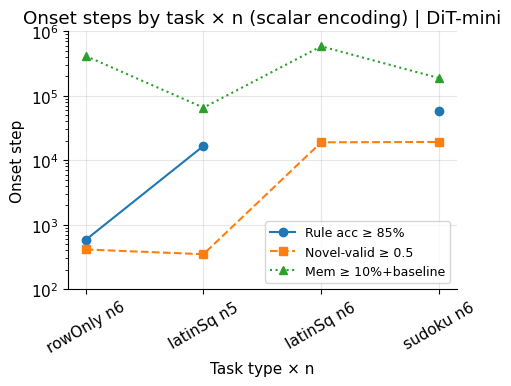

In [123]:
grid_tasks = df[df['task_type'].isin(['rowOnly', 'latinSq', 'sudoku'])].copy()

# Filter for scalar encoding only
scalar_tasks = grid_tasks.query("encoding=='scalar' and model_size=='mini'").copy()

# Build a combined x-axis key: "tasktype n{n_size}"
scalar_tasks['task_n'] = scalar_tasks.apply(lambda row: f"{row['task_type']} n{int(row['n_size'])}" if not pd.isna(row['n_size']) else row['task_type'], axis=1)

# Sort by task type (original order) and n_size
scalar_tasks['task_type'] = pd.Categorical(scalar_tasks['task_type'], categories=['rowOnly', 'latinSq', 'sudoku'], ordered=True)
scalar_tasks = scalar_tasks.sort_values(['task_type', 'n_size'])

fig, ax = plt.subplots(figsize=(5, 4))

x_vals = scalar_tasks['task_n']
x_ind = np.arange(len(x_vals))

for col, label, style in [
    ('rule_onset_acc85', 'Rule acc ≥ 85%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    y = scalar_tasks[col]
    ax.plot(x_ind, y, label=label, **style)

ax.set_xticks(x_ind)
ax.set_xticklabels(x_vals, rotation=30)
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('Task type × n')
ax.set_ylabel('Onset step')
ax.set_title('Onset steps by task × n (scalar encoding) | DiT-mini')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
saveallforms(FIGDIR, 'DiT-mini_scalar_latinsq_sudoku_tasks_rule_mem_onset_vs_taskxn', fig)
plt.show()

In [122]:
FIGDIR

'/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/beyond_parity_figures'

In [120]:
grid_tasks

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
0,DiT_B_latinSq_n5_N4096_onehot,latinSq,DiT,B,1,4096,5.0,NaN,NaN,NaN,...,40208.0,NaN,59216.0,444064.0,NaN,NaN,140960.0,1412.0,6280.0,NaN
1,DiT_B_latinSq_n5_N4096_scalar,latinSq,DiT,B,1,4096,5.0,NaN,NaN,NaN,...,9224.0,NaN,28688.0,50512.0,458400.0,516768.0,31504.0,268.0,340.0,14352.0
2,DiT_B_latinSq_n6_N4096_onehot,latinSq,DiT,B,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2724.0,19984.0,NaN
3,DiT_B_latinSq_n6_N4096_scalar,latinSq,DiT,B,1,4096,6.0,NaN,NaN,NaN,...,24848.0,NaN,174752.0,212640.0,271008.0,356000.0,174752.0,548.0,7560.0,85840.0
13,DiT_mini_latinSq_n5_N4096_onehot,latinSq,DiT,mini,1,4096,5.0,NaN,NaN,NaN,...,63312.0,NaN,112288.0,NaN,NaN,NaN,194208.0,3460.0,10768.0,NaN
14,DiT_mini_latinSq_n5_N4096_scalar,latinSq,DiT,mini,1,4096,5.0,NaN,NaN,NaN,...,16656.0,NaN,59216.0,116384.0,832160.0,975520.0,65360.0,340.0,348.0,33040.0
15,DiT_mini_latinSq_n6_N4096_onehot,latinSq,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11280.0,43792.0,NaN
16,DiT_mini_latinSq_n6_N4096_onehot_zeromean_autoSD,latinSq,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,258720.0,NaN,NaN,NaN,NaN,NaN,NaN,2564.0,17424.0,NaN
17,DiT_mini_latinSq_n6_N4096_onehot_zeroone_autoSD,latinSq,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,465568.0,NaN,NaN,NaN,NaN,NaN,NaN,3556.0,19216.0,NaN
18,DiT_mini_latinSq_n6_N4096_scalar,latinSq,DiT,mini,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,585376.0,884384.0,NaN,NaN,585376.0,772.0,18960.0,NaN


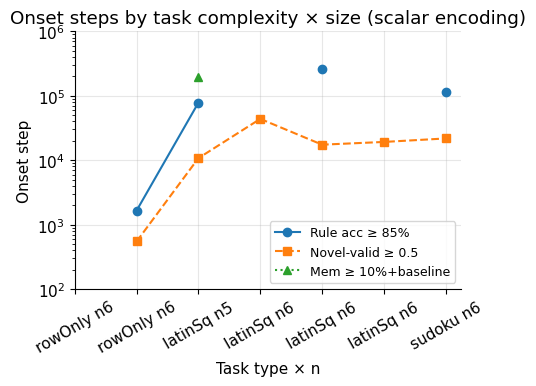

In [ ]:
grid_tasks = df[df['task_type'].isin(['rowOnly', 'latinSq', 'sudoku'])].copy()

# Filter for scalar encoding only
scalar_tasks = grid_tasks.query("encoding=='onehot' and model_size=='mini'").copy()

# Build a combined x-axis key: "tasktype n{n_size}"
scalar_tasks['task_n'] = scalar_tasks.apply(lambda row: f"{row['task_type']} n{int(row['n_size'])}" if not pd.isna(row['n_size']) else row['task_type'], axis=1)

# Sort by task type (original order) and n_size
scalar_tasks['task_type'] = pd.Categorical(scalar_tasks['task_type'], categories=['rowOnly', 'latinSq', 'sudoku'], ordered=True)
scalar_tasks = scalar_tasks.sort_values(['task_type', 'n_size'])

fig, ax = plt.subplots(figsize=(5, 4))

x_vals = scalar_tasks['task_n']
x_ind = np.arange(len(x_vals))

for col, label, style in [
    ('rule_onset_acc85', 'Rule acc ≥ 85%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    y = scalar_tasks[col]
    ax.plot(x_ind, y, label=label, **style)

ax.set_xticks(x_ind)
ax.set_xticklabels(x_vals, rotation=30)
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('Task type × n')
ax.set_ylabel('Onset step')
ax.set_title('Onset steps by task complexity × size (onehot encoding)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
saveallforms(FIGDIR, 'DiT-mini_onehot_latinsq_sudoku_tasks_rule_mem_onset_vs_taskxn', fig)
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

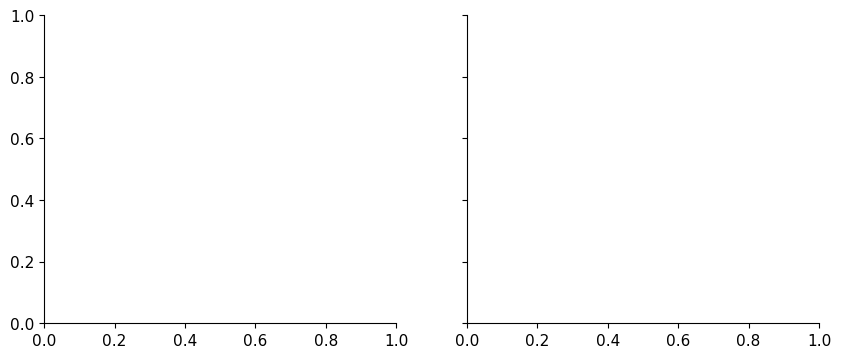

In [17]:
# Bar chart: rule onset comparison across rule complexity
RULE_ORDER = ['rowOnly', 'latinSq', 'sudoku']
RULE_LABELS = ['Row-only', 'Latin square\n(row+col)', 'Sudoku 6×6\n(row+col+block)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, enc in zip(axes, ['scalar', 'onehot']):
    sub = grid_tasks[grid_tasks['encoding'] == enc].set_index('task_type')
    rule_onsets = [sub.loc[tt, 'rule_onset_acc90'] / 1000 if tt in sub.index
                   and not pd.isna(sub.loc[tt, 'rule_onset_acc90'])
                   else np.nan for tt in RULE_ORDER]
    novel_onsets = [sub.loc[tt, 'novel_onset_05'] / 1000 if tt in sub.index
                    and not pd.isna(sub.loc[tt, 'novel_onset_05'])
                    else np.nan for tt in RULE_ORDER]

    x = np.arange(len(RULE_ORDER))
    w = 0.35
    bars1 = ax.bar(x - w/2, rule_onsets,  width=w, label='Rule onset acc90',  alpha=0.85,
                   color=[TASK_COLORS.get(t, 'gray') for t in RULE_ORDER])
    bars2 = ax.bar(x + w/2, novel_onsets, width=w, label='Novel-valid onset 0.5', alpha=0.55,
                   color=[TASK_COLORS.get(t, 'gray') for t in RULE_ORDER], hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(RULE_LABELS, fontsize=9)
    ax.set_title(f'Encoding: {enc}')
    ax.set_ylabel('Onset step (k)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('DiT-mini n=6: Rule complexity vs onset steps', fontsize=12)
plt.tight_layout()
plt.show()

## 7. exactK: onset vs K (sparsity)

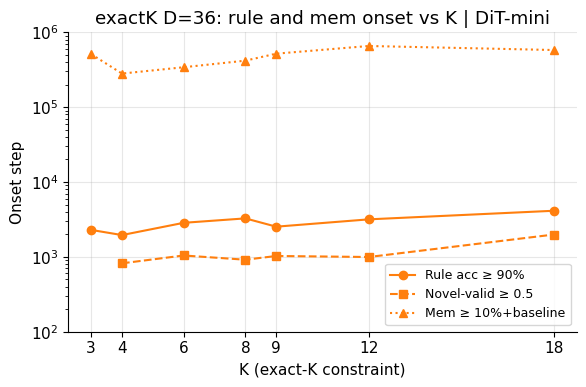

In [84]:
ek = df[df['task_type'] == 'exactK'].copy().sort_values('K')

fig, ax = plt.subplots(figsize=(6, 4))

for col, label, style in [
    ('rule_onset_acc90', 'Rule acc ≥ 90%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    mask = ek[col].notna()
    ax.plot(ek[mask]['K'], ek[mask][col],
            color=TASK_COLORS['exactK'], label=label, **style)

# Set xticks only at K values that actually exist in the data
xticks = ek['K'].dropna().unique()
ax.set_xticks(xticks)
ax.set_xticklabels([str(int(x)) for x in xticks])
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('K (exact-K constraint)')
ax.set_ylabel('Onset step')
ax.set_title('exactK D=36: rule and mem onset vs K | DiT-mini')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
saveallforms(FIGDIR, 'DiT-mini_exactK_rule_mem_onset_vs_K', fig)
plt.show()

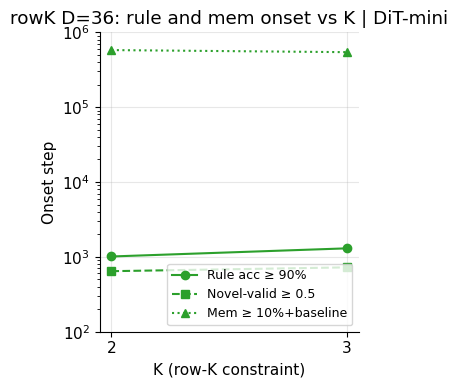

In [104]:
rk = df.query("task_type=='rowK'").copy().sort_values('K')

fig, ax = plt.subplots(figsize=(3.5, 4))

for col, label, style in [
    ('rule_onset_acc90', 'Rule acc ≥ 90%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    mask = rk[col].notna()
    ax.plot(rk[mask]['K'], rk[mask][col],
            color=TASK_COLORS['rowK'], label=label, **style)

# Set xticks only at K values that actually exist in the data
xticks = rk['K'].dropna().unique()
ax.set_xticks(xticks)
ax.set_xticklabels([str(int(x)) for x in xticks])
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('K (row-K constraint)')
ax.set_ylabel('Onset step')
ax.set_title('rowK D=36: rule and mem onset vs K | DiT-mini')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
ax.legend(fontsize=9, loc='lower right')
saveallforms(FIGDIR, 'DiT-mini_rowK_rule_mem_onset_vs_K', fig)
plt.show()

In [92]:
df.task_type.unique()

['latinSq', 'exactK', 'globalK', 'parity', 'rowK', 'rowOnly', 'rowVarK', 'sudoku']
Categories (8, object): ['parity' < 'exactK' < 'rowK' < 'rowVarK' < 'globalK' < 'rowOnly' < 'latinSq' < 'sudoku']

In [97]:
rvk[mask]['K_list']

52    [0, 2, 4, 6]
53          [1, 5]
54    [3, 4, 5, 6]
55          [3, 4]
Name: K_list, dtype: object

In [108]:
df.query("task_type=='rowVarK'")[['K_list', 'rule_onset_acc90', 'novel_onset_05', 'novel_onset_09', 'mem_onset_stat']]

,K_list,rule_onset_acc90,novel_onset_05,novel_onset_09,mem_onset_stat
52,"[0, 2, 4, 6]",8456.0,4964.0,8456.0,373408.0
53,"[1, 5]",3044.0,1300.0,3044.0,383648.0
54,"[3, 4, 5, 6]",21008.0,324.0,21008.0,349856.0
55,"[3, 4]",2500.0,588.0,2500.0,473760.0


/tmp/ipykernel_1827802/891988646.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(x) for x in xticks])


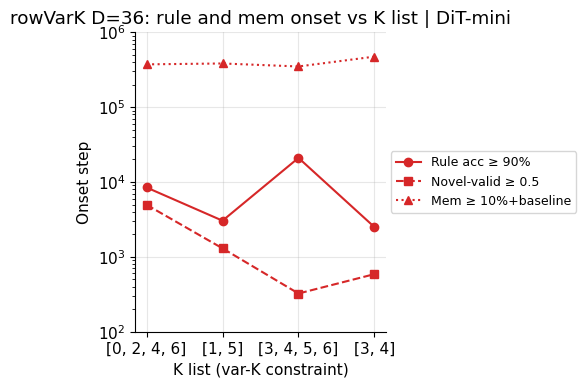

In [102]:
rvk = df.query("task_type=='rowVarK'").copy().sort_values('K')

fig, ax = plt.subplots(figsize=(3.5, 4))

for col, label, style in [
    ('rule_onset_acc90', 'Rule acc ≥ 90%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    mask = rvk[col].notna()
    ax.plot(rvk[mask]['K_list'], rvk[mask][col],
            color=TASK_COLORS['rowVarK'], label=label, **style)

# Set xticks only at K values that actually exist in the data
xticks = rvk['K_list'].dropna().unique()
# ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('K list (var-K constraint)')
ax.set_ylabel('Onset step')
ax.set_title('rowVarK D=36: rule and mem onset vs K list | DiT-mini')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
# Move legend to the right outside the frame
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
saveallforms(FIGDIR, 'DiT-mini_rowVarK_rule_mem_onset_vs_Klist', fig)
plt.show()

/tmp/ipykernel_1827802/1400818429.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(x) for x in xticks])


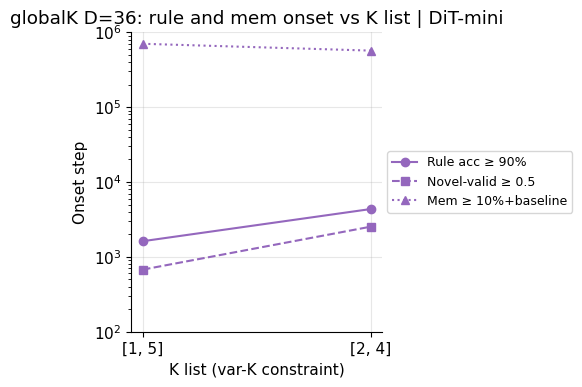

In [103]:
rGk = df.query("task_type=='globalK'").copy().sort_values('K')

fig, ax = plt.subplots(figsize=(3.5, 4))

for col, label, style in [
    ('rule_onset_acc90', 'Rule acc ≥ 90%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    mask = rGk[col].notna()
    ax.plot(rGk[mask]['K_list'], rGk[mask][col],
            color=TASK_COLORS['globalK'], label=label, **style)

# Set xticks only at K values that actually exist in the data
xticks = rGk['K_list'].dropna().unique()
# ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('K list (var-K constraint)')
ax.set_ylabel('Onset step')
ax.set_title('globalK D=36: rule and mem onset vs K list | DiT-mini')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
# Move legend to the right outside the frame
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
saveallforms(FIGDIR, 'DiT-mini_globalK_rule_mem_onset_vs_Klist', fig)
plt.show()

In [36]:
df.query("task_type=='rowOnly'")

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,col_onset_90,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09
49,DiT_mini_rowOnly_n6_N4096_onehot,rowOnly,DiT,unknown,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,DiT_mini_rowOnly_n6_N4096_onehot_zeromean_autoSD,rowOnly,DiT,unknown,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,452.0,548.0,1700.0
51,DiT_mini_rowOnly_n6_N4096_scalar,rowOnly,DiT,unknown,1,4096,6.0,NaN,NaN,NaN,...,NaN,NaN,415392.0,605856.0,951968.0,NaN,415392.0,252.0,412.0,596.0


In [ ]:
ek = df[df['task_type'] == 'rowK'].copy().sort_values('K')

fig, ax = plt.subplots(figsize=(6, 4))

for col, label, style in [
    ('rule_onset_acc90', 'Rule acc ≥ 90%',  dict(marker='o', ls='-')),
    ('novel_onset_05',   'Novel-valid ≥ 0.5', dict(marker='s', ls='--')),
    ('mem_onset_stat',  'Mem ≥ 10%+baseline',        dict(marker='^', ls=':')),
]:
    mask = ek[col].notna()
    ax.plot(ek[mask]['K'], ek[mask][col],
            color=TASK_COLORS['rowK'], label=label, **style)

# Set xticks only at K values that actually exist in the data
xticks = ek['K'].dropna().unique()
ax.set_xticks(xticks)
ax.set_xticklabels([str(int(x)) for x in xticks])
ax.set_ylim(1E2, 1E6)
ax.set_yscale('log')
ax.set_xlabel('K (exact-K constraint)')
ax.set_ylabel('Onset step')
ax.set_title('exactK D=36: rule and mem onset vs K')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Memorization vs rule onset: mem_onset vs rule_onset across all tasks

In [ ]:
df_m = df[
    df['rule_onset_acc90'].notna() &
    df['mem_onset_mem10'].notna()
].copy()

fig, ax = plt.subplots(figsize=(7, 6))

for tt in TASK_ORDER:
    sub = df_m[df_m['task_type'] == tt]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['rule_onset_acc90'] / 1000,
        sub['mem_onset_mem10'] / 1000,
        color=TASK_COLORS[tt], s=60, alpha=0.8, label=tt, zorder=3
    )

lims = [0, df_m[['rule_onset_acc90','mem_onset_mem10']].max().max() / 1000 * 1.05]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Rule onset acc90 (k steps)')
ax.set_ylabel('Mem onset ≥10% (k steps)')
ax.set_title('Memorization onset vs rule-learning onset\n(above diagonal → rule first, below → mem first)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. stat_mem_frac as predictor of rule onset (across all tasks)

In [ ]:
df_pred = df[
    df['stat_mem_frac'].notna() &
    df['rule_onset_acc90'].notna()
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for tt in TASK_ORDER:
    sub = df_pred[df_pred['task_type'] == tt]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['stat_mem_frac'],
        sub['rule_onset_acc90'] / 1000,
        color=TASK_COLORS[tt], s=60, alpha=0.8, label=tt, zorder=3
    )

ax.set_xscale('log')
ax.set_xlabel('N / support_size  (log scale)')
ax.set_ylabel('Rule onset acc90 (k steps)')
ax.set_title('Data coverage vs rule-learning difficulty')
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()